#Libraries

In [8]:
# Data handling and plotting
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# DATA PREPROCESSING
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#statistics
from scipy import stats

# Cross - validation, hyperparameter tuning (k-fold,grid)
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold


#Reading Dataset


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
filepath = "/content/drive/MyDrive/DATA/dataset[1].csv"
ast_df = pd.read_csv(filepath)

/tmp/ipykernel_1208/342977283.py:2: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  ast_df = pd.read_csv(filepath)


In [10]:
print("Shape (rows, columns):", ast_df.shape)
ast_df.head()

Shape (rows, columns): (958524, 45)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


#EDA


In [11]:
ast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [12]:
ast_df.head()

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [13]:
ast_df.shape

(958524, 45)

In [14]:
ast_df.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


In [15]:
ast_df.columns

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='object')

## what the columns mean and what to do with them

In [28]:
###Identifiers & Names
# id: Internal database ID for the record.
# spkid: Unique SPK-ID integer identifier assigned by NASA/JPL.
# full_name: The full official designation or name of the asteroid.
# pdes: Primary provisional designation (e.g., 2001 AE2).
# name: IAU-approved proper name, if it has one (e.g., Ceres, Eros).
# prefix: Rare statistical or catalog prefix flags

# Decision
# will drop the identifiersand names since they have zero predictive power amd may result in future overfitting.

In [41]:
### Classification & Flags
# neo: Near-Earth Object flag (Y or N).
# pha: Potentially Hazardous Asteroid flag (Y or N).
# class: Orbital classification code (e.g., MBA for Main-Belt Asteroid, AMO for Amor).
#will keep or drop after further inspection

In [42]:
### Physical Characteristics
# H: Absolute magnitude (intrinsic brightness).
# diameter: Estimated size/diameter of the asteroid in kilometers.
# albedo: Geometric albedo (surface reflectivity scale from 0 to 1).
# diameter_sigma: 1-sigma measurement uncertainty for the diameter

#will keep or drop after further inspection

In [23]:
#Orbital Parameters & Mechanics
'''• orbit_id: Identifier for the specific orbital solution.
• epoch / epoch_mjd / epoch_cal: Reference time (epoch) of the orbital calculation in Julian Date, Modified Julian Date, or calendar format.
• equinox: Reference frame equinox (e.g., J2000).
• e: Orbital eccentricity (how stretched the orbit is).
• a: Semi-major axis in Astronomical Units (AU), representing average distance from the Sun.
• q: Perihelion distance in AU (closest point to the Sun).
• i: Inclination angle relative to Earth's orbital plane (degrees).
• om: Longitude of the ascending node (degrees).
• w: Argument of perihelion (degrees).
• ma: Mean anomaly (degrees position in orbit).
• ad: Aphelion distance in AU (farthest point from the Sun).
• n: Mean daily motion (degrees per day).
• tp / tp_cal: Time of perihelion passage (date/time when closest to the Sun).
• per / per_y: Orbital period measured in days (per) and years (per_y).
• moid / moid_ld: Minimum Orbit Intersection Distance with Earth, measured in AU (moid) and Lunar Distances (moid_ld)'''
#will keep after furrther inspection

"• orbit_id: Identifier for the specific orbital solution.\n• epoch / epoch_mjd / epoch_cal: Reference time (epoch) of the orbital calculation in Julian Date, Modified Julian Date, or calendar format.\n• equinox: Reference frame equinox (e.g., J2000).\n• e: Orbital eccentricity (how stretched the orbit is).\n• a: Semi-major axis in Astronomical Units (AU), representing average distance from the Sun.\n• q: Perihelion distance in AU (closest point to the Sun).\n• i: Inclination angle relative to Earth's orbital plane (degrees).\n• om: Longitude of the ascending node (degrees).\n• w: Argument of perihelion (degrees).\n• ma: Mean anomaly (degrees position in orbit).\n• ad: Aphelion distance in AU (farthest point from the Sun).\n• n: Mean daily motion (degrees per day).\n• tp / tp_cal: Time of perihelion passage (date/time when closest to the Sun).\n• per / per_y: Orbital period measured in days (per) and years (per_y).\n• moid / moid_ld: Minimum Orbit Intersection Distance with Earth, meas

In [24]:
# Uncertainties & Fit Quality (sigma_* and rms)
# sigma_e, sigma_a, sigma_q, sigma_i, sigma_om, sigma_w, sigma_ma, sigma_ad, sigma_n, sigma_tp, sigma_per: Statistical 1-sigma uncertainty margins for each corresponding orbital attribute.
# rms: Root Mean Square error of the orbital fit, showing how well the orbit model matches observational tracking data.

## Checking Duplicates and Missing values

In [25]:
ast_df.duplicated().sum()

np.int64(0)

In [43]:
#no duplicate values present hence no further duplicate treatment required.

In [32]:
ast_df.isna().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


## identifying unique values,categorical and numerical columns

In [26]:
ast_df.nunique()

,0
id,958524
spkid,958524
full_name,958524
pdes,958524
name,22064
prefix,1
neo,2
pha,2
H,9489
diameter,16591


In [31]:
#numerical columns
numerical_cols =ast_df.select_dtypes(include=[np.number]).columns.tolist()

#categorical columns
categorical_cols =ast_df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print(f"\nTotal numerical columns: {len(numerical_cols)}")
print(f"Total categorical columns: {len(categorical_cols)}")


Numerical columns: ['spkid', 'H', 'diameter', 'albedo', 'diameter_sigma', 'epoch', 'epoch_mjd', 'epoch_cal', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms']
Categorical columns: ['id', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'orbit_id', 'equinox', 'class']

Total numerical columns: 35
Total categorical columns: 10


In [ ]:
#Large number of missing value cannot be imputed and will be removed later.

In [ ]:
#Target = Diameter

In [34]:
ast_df['diameter'].describe()

,diameter
count,136209.000000
mean,5.506429
std,9.425164
min,0.002500
25%,2.780000
50%,3.972000
75%,5.765000
max,939.400000


In [35]:
ast_df['diameter'].isna().sum()

np.int64(822315)

In [ ]:
#major missing values from the target columns will be removed later since no pattern recognition can be made from it

##Univariate Analysis

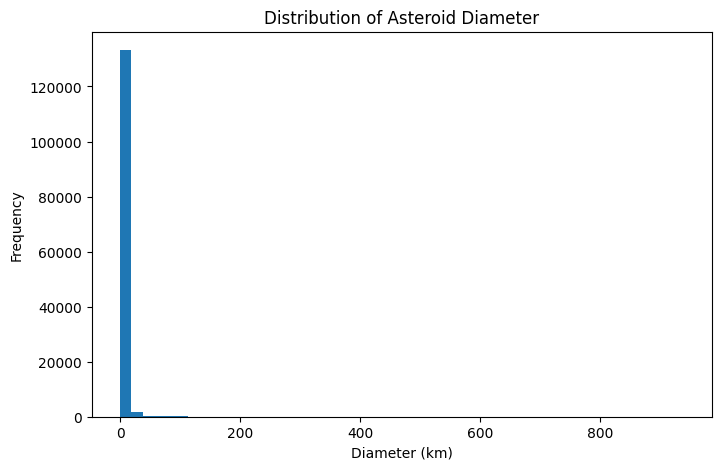

In [45]:
plt.figure(figsize=(8,5))
plt.hist(ast_df['diameter'].dropna(), bins=50)
plt.xlabel('Diameter (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Asteroid Diameter')
plt.show()

In [ ]:
#Diameter distribution-diameter is highly right-skewed mostly missing values diamter of an asteroid can never be zero
#and most asteroids being small and a few having very large diameters.

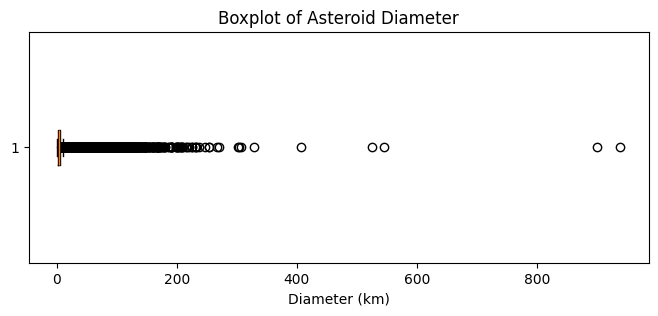

In [47]:
plt.figure(figsize=(8,3))
plt.boxplot(ast_df['diameter'].dropna(), vert=False)
plt.xlabel('Diameter (km)')
plt.title('Boxplot of Asteroid Diameter')
plt.show()

In [ ]:
#Diameter boxplotdiameter contains many statistical outliers including several very large asteroids.
#They should not be removed automatically.

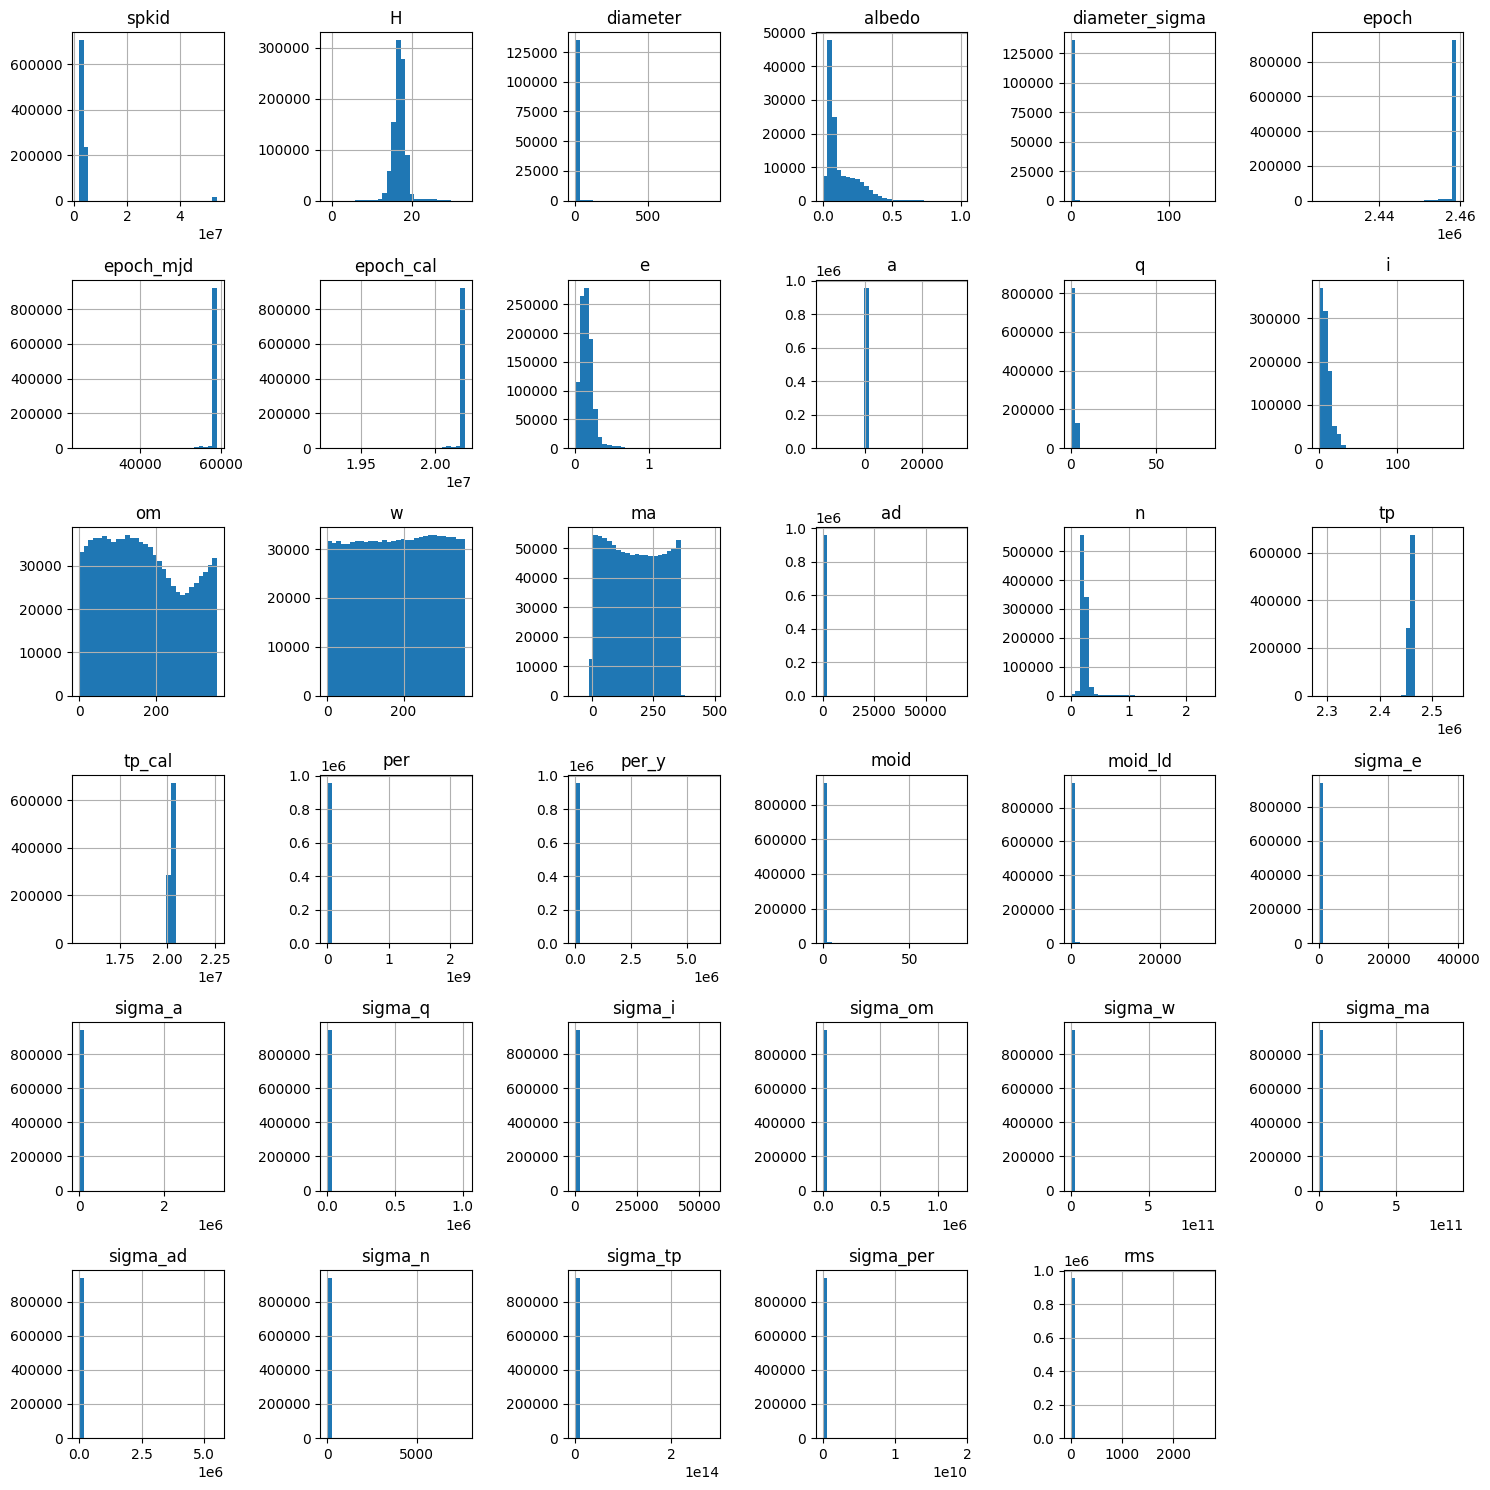

In [50]:
numeric_cols = ast_df.select_dtypes(include='number').columns

ast_df[numeric_cols].hist(figsize=(15,15), bins=30)
plt.tight_layout()
plt.show()

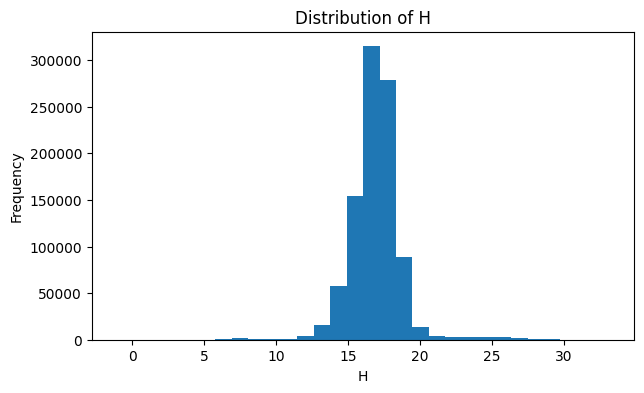

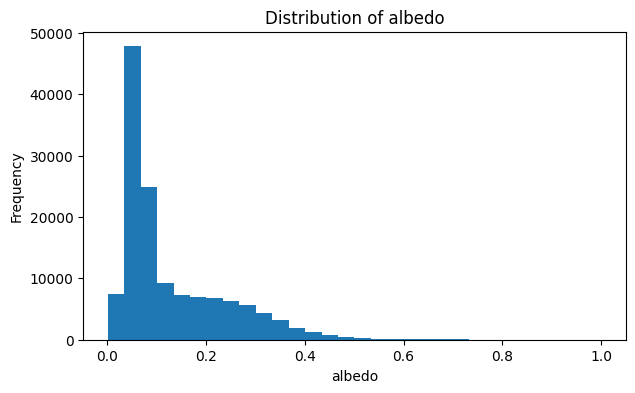

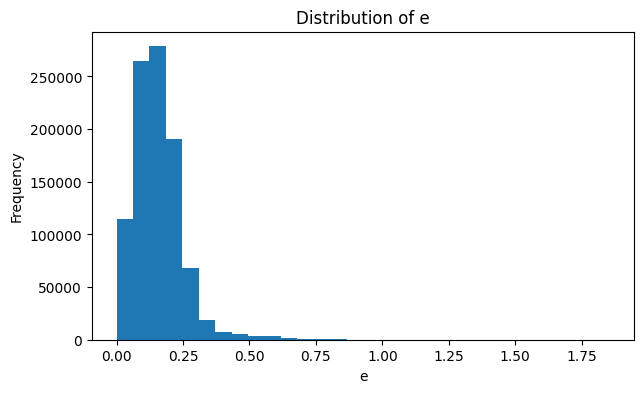

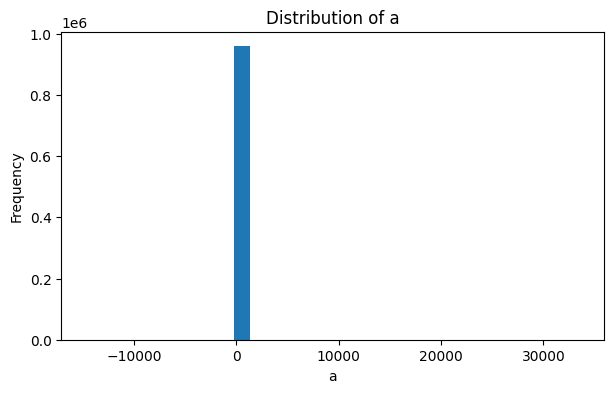

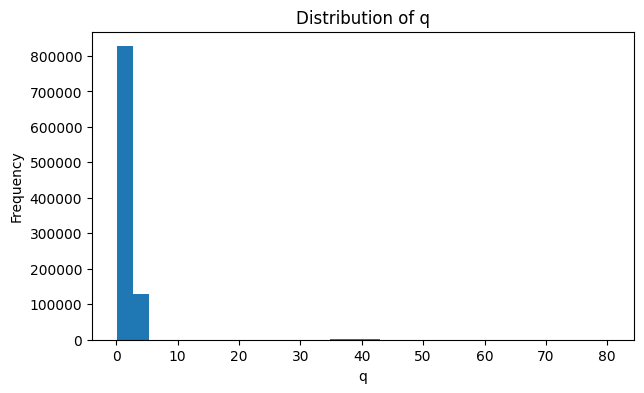

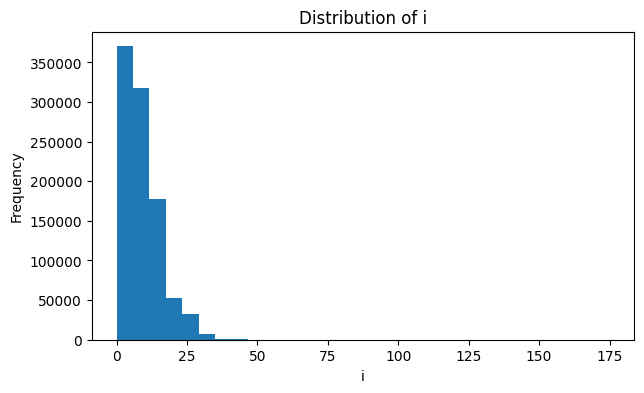

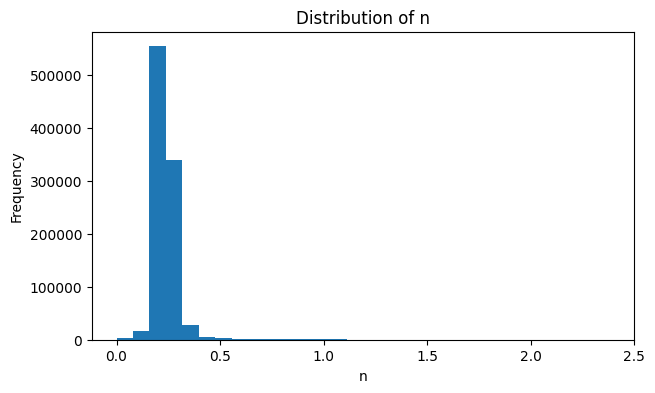

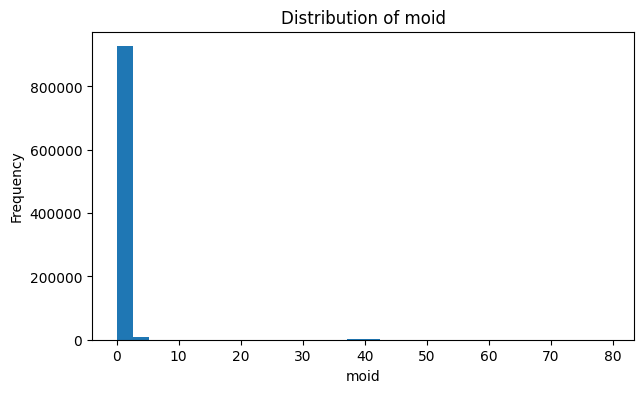

In [53]:
cols = ['H', 'albedo', 'e', 'a', 'q', 'i', 'n', 'moid']

for col in cols:
    plt.figure(figsize=(7,4))
    plt.hist(ast_df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

In [55]:
'''Univariate analysis inferences
H distribution-Most H values are concentrated around 15–20, with a few extreme values on both ends.
Feature distributions-Many numerical features (e, q, i, n, moid, etc.) are right-skewed, while om and w are relatively more uniform.



Overall-The data has substantial skewness and extreme values, so transformation/scaling will likely be the next procedure'''

'Univariate analysis — concise inferences\nH distribution-Most H values are concentrated around 15–20, with a few extreme values on both ends.\nFeature distributions-Many numerical features (e, q, i, n, moid, etc.) are right-skewed, while om and w are relatively more uniform.\nDiameter boxplot-diameter contains many statistical outliers, including several very large asteroids. They should not be removed automatically.\nDiameter distribution-diameter is highly right-skewed, with most asteroids being small and a few having very large diameters.\n\nOverall-The data has substantial skewness and extreme values, so transformation/scaling will likely be the next procedure'

In [56]:
#Since there are so many missing values from the target column lets handle the mising value (rermoving one ) first and then do correlation.


##Missing Value handling

In [57]:
ast_df = ast_df[ast_df['diameter'].notna()].copy()

ast_df.shape


(136209, 45)

In [62]:
missing_valu = (ast_df.isnull().sum() / len(ast_df) * 100).sort_values(ascending=False)

missing_valu


,0
id,0.0
spkid,0.0
full_name,0.0
pdes,0.0
neo,0.0
pha,0.0
H,0.0
diameter,0.0
albedo,0.0
orbit_id,0.0


In [70]:
ast_df = ast_df.drop(columns=['prefix', 'name', 'diameter_sigma'], errors='ignore')

In [60]:
#prefix	100% missing so dropping since it has no info
#name	88.87% dropping its mostly missing and identifiers

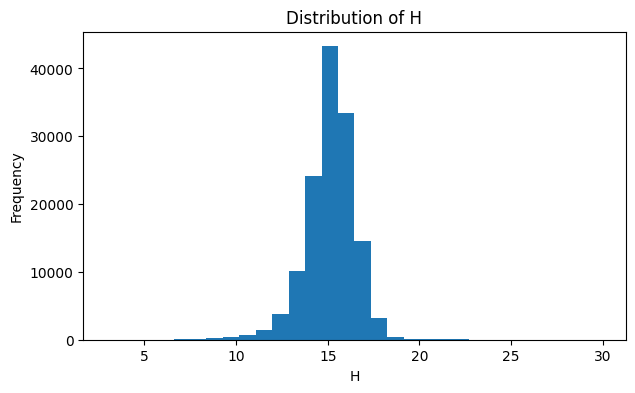

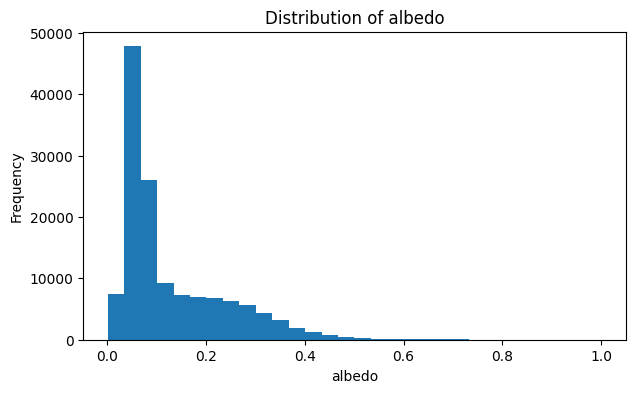

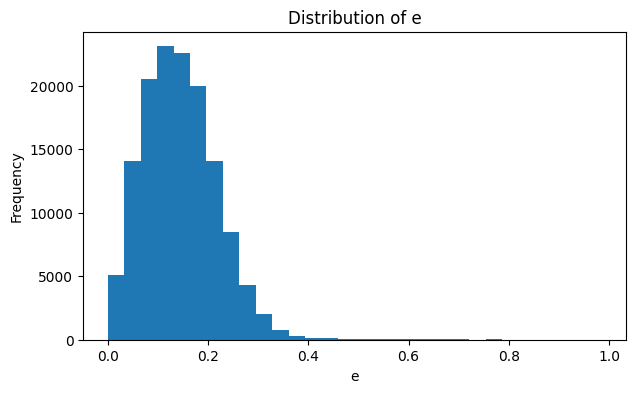

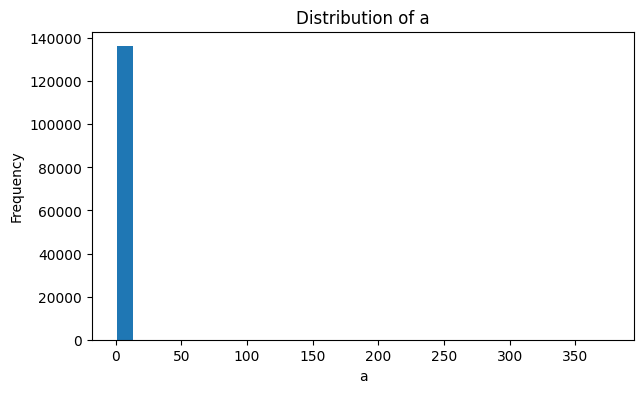

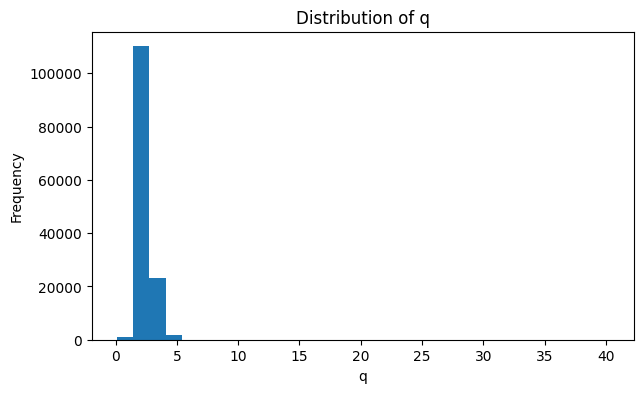

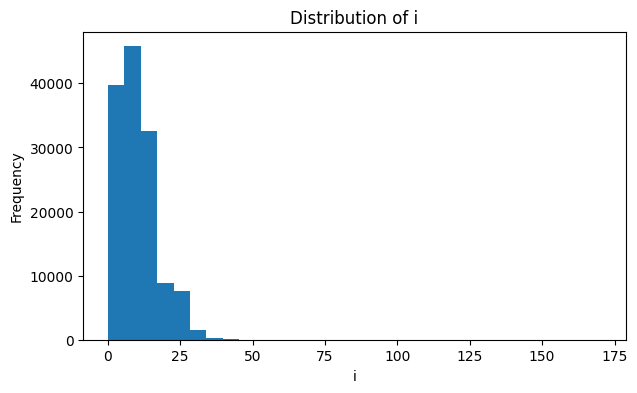

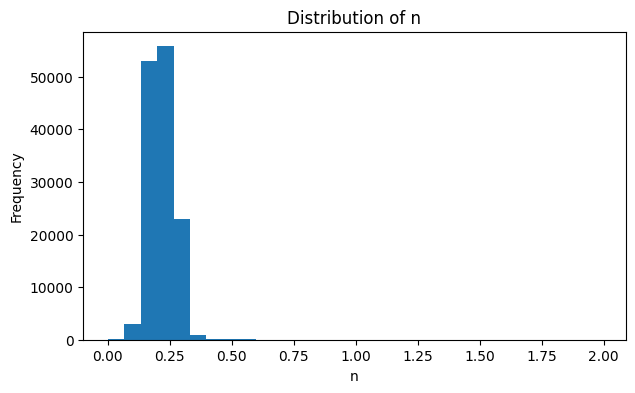

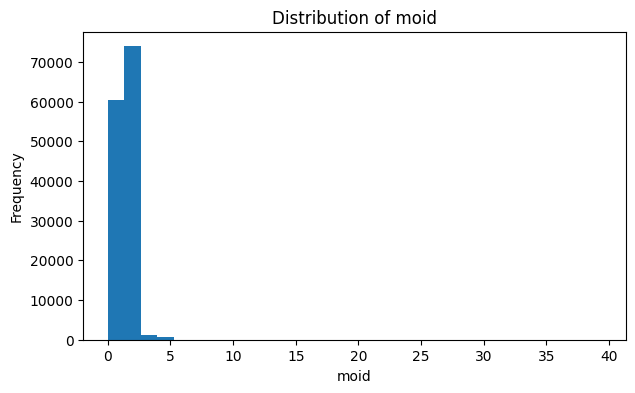

In [71]:
cols = ['H', 'albedo', 'e', 'a', 'q', 'i', 'n', 'moid']

for col in cols:
    plt.figure(figsize=(7,4))
    plt.hist(ast_df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

In [61]:
ast_df['H'] = ast_df['H'].fillna(ast_df['H'].median())
ast_df['albedo'] = ast_df['albedo'].fillna(ast_df['albedo'].median())

In [ ]:
# busing median imputation because both variables are mostly skewed even after and median is less affected by extreme values

In [74]:
missing_valu = (ast_df.isnull().sum() / len(ast_df) * 100).sort_values(ascending=False)
missing_valu

,0
id,0.0
spkid,0.0
full_name,0.0
pdes,0.0
neo,0.0
pha,0.0
H,0.0
diameter,0.0
albedo,0.0
orbit_id,0.0


In [73]:
ast_df.isnull().sum().sum()

np.int64(0)

##Bivariate Analysis

In [75]:
corr = ast_df.select_dtypes(include='number').corr()['diameter'].sort_values(ascending=False)

corr

,diameter
diameter,1.000000
moid,0.331983
moid_ld,0.331983
q,0.329223
a,0.146799
ad,0.094735
epoch_cal,0.058539
epoch,0.058475
epoch_mjd,0.058475
i,0.054963


Correlation inference
H: strongest negative correlation with diameter −0.572
moid / moid_ld: moderate positive correlation ~0.332
q: moderate positive correlation 0.329
n: weak-to-moderate negative correlation −0.199.
rms: weak negative correlation -0.182.
albedo: weak negative correlation −0.108.

Most remaining variables have weak or negligible linear correlation with diameter.

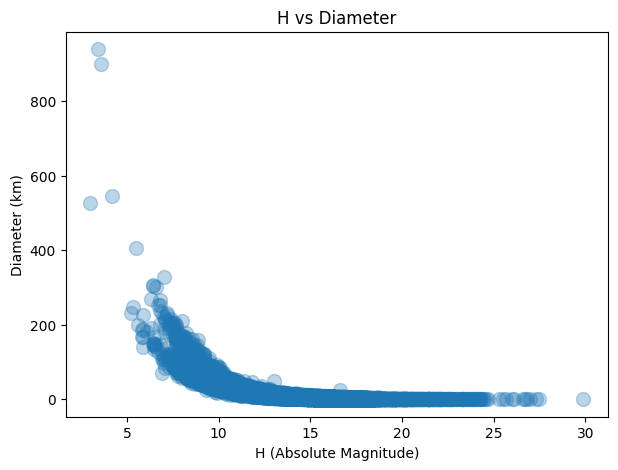

In [79]:
plt.figure(figsize=(7,5))
plt.scatter(
    ast_df['H'],
    ast_df['diameter'],
    alpha=0.3,
    s=100
)

plt.xlabel('H (Absolute Magnitude)')
plt.ylabel('Diameter (km)')
plt.title('H vs Diameter')

plt.show()

In [ ]:
#strong inverse relationship#
#As H increases, diameter generally decreases.
#so we consider it importanat even thought its a negative correaltion


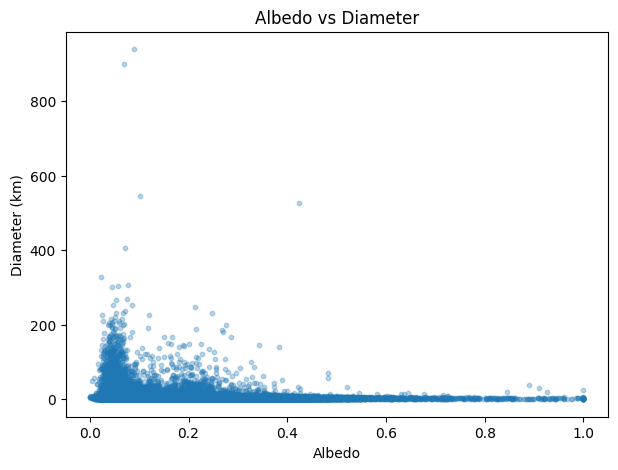

In [82]:
plt.figure(figsize=(7,5))

plt.scatter(
    ast_df['albedo'],
    ast_df['diameter'],
    alpha=0.3,
    s=10
)

plt.xlabel('Albedo')
plt.ylabel('Diameter (km)')
plt.title('Albedo vs Diameter')

plt.show()

In [ ]:
#Analytical qns
#1.No. diameter is not normally distributed.highly right skewed till missing value handling
#2Feature Correlation with diameter H −0.572moid +0.332 q +0.329 n −0.199 rms −0.182albedo −0.108 h has highst iverse coorelation  and moid has positive




#preprocessing and feature engineering

In [ ]:
#Missing values handled before bivariate analysis.


##Outlier handling

In [83]:
Q1 = ast_df['diameter'].quantile(0.25)
Q3 = ast_df['diameter'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ast_df[
    (ast_df['diameter'] < lower_bound) |
    (ast_df['diameter'] > upper_bound)
]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outliers:", len(outliers))
print("Outlier %:", len(outliers) / len(ast_df) * 100)

Q1: 2.78
Q3: 5.765
IQR: 2.985
Lower Bound: -1.6975000000000002
Upper Bound: 10.2425
Outliers: 9613
Outlier %: 7.057536579814844


## data transformation

In [84]:
ast_df['diameter_log'] = np.log1p(ast_df['diameter'])

In [85]:
ast_df['diameter_log'].describe()

,diameter_log
count,136209.000000
mean,1.669738
std,0.523468
min,0.002497
25%,1.329724
50%,1.603822
75%,1.911762
max,6.846305


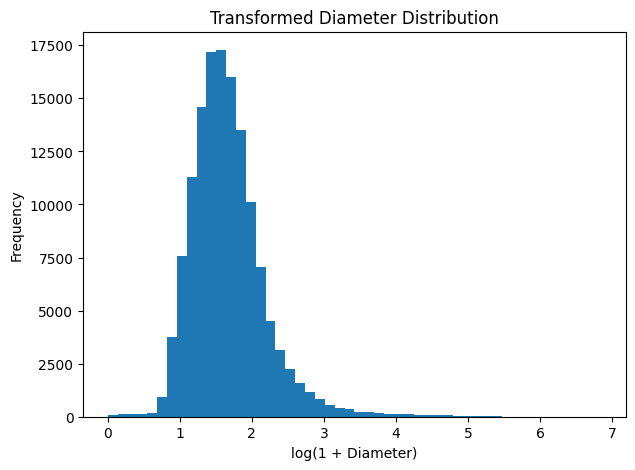

In [86]:
plt.figure(figsize=(7,5))
plt.hist(ast_df['diameter_log'], bins=50)
plt.xlabel('log(1 + Diameter)')
plt.ylabel('Frequency')
plt.title('Transformed Diameter Distribution')
plt.show()


In [87]:
#or DNN regression
#a highly skewed target can result in loss so using log transformation.

##Feature Selection

In [88]:
features = [
    'H',
    'albedo',
    'e',
    'a',
    'q',
    'i',
    'n',
    'moid'
]

X = ast_df[features]
y = ast_df['diameter_log']

print(X.shape)
print(X.columns)

(136209, 8)
Index(['H', 'albedo', 'e', 'a', 'q', 'i', 'n', 'moid'], dtype='object')


In [90]:
##we are doing train test split next to avoid data leakage.We split before scaling because the scaler must learn its meanor std only from the training data.

##train test Split


In [89]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (108967, 8)
X_test: (27242, 8)
y_train: (108967,)
y_test: (27242,)


## Scaling

In [94]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))#verfiication

[-9.84432322e-16 -1.29566604e-16 -1.40227973e-16  6.35769699e-17
  6.02905296e-16 -9.98973516e-17  9.46669232e-16 -7.95853248e-17]
[1. 1. 1. 1. 1. 1. 1. 1.]


In [98]:
#Anlytical qns
#1.else it will result in loss.
#2.ids names timestamps uncertainity columns redudant features target reted diamtert_sigma these features were removes most of em are identifires or less correlation
#3.Improves learning

##Encoding

In [ ]:
#no encoding is required since the models we selected are numerical.

#Model building

In [99]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0714 - mae: 0.1106 - val_loss: 0.0160 - val_mae: 0.0798
Epoch 2/50
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0185 - mae: 0.0809 - val_loss: 0.0131 - val_mae: 0.0763
Epoch 3/50
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0460 - mae: 0.0781 - val_loss: 0.0126 - val_mae: 0.0749
Epoch 4/50
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0129 - mae: 0.0736 - val_loss: 0.0113 - val_mae: 0.0700
Epoch 5/50
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0122 - mae: 0.0720 - val_loss: 0.0110 - val_mae: 0.0693
Epoch 6/50
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0126 - mae: 0.0710 - val_loss: 0.0114 - val_mae: 0.0717
Epoch 7/50
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0113 - mae: 0.0707 - val_loss: 0.0105 - val_mae: 0.0702
Epoch 8/50
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0108 - mae: 0.0695 - val_loss: 0.0104 - val_mae: 0.0702
Epoch 9/50
2725/2725 ━━━━━━━━━━━━━━━━

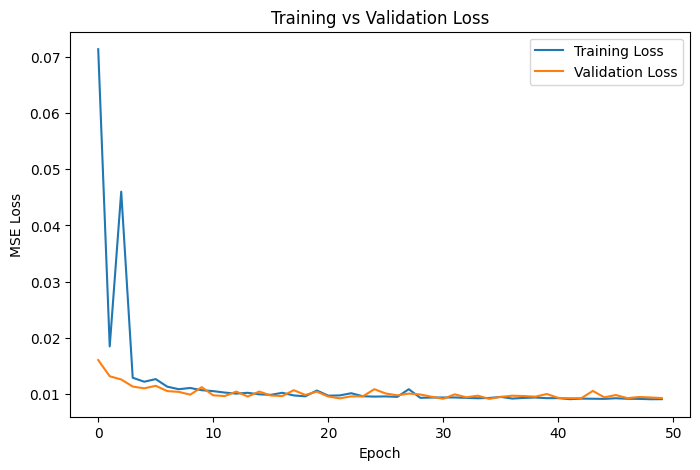

In [103]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
'''analytical qns
1. we are predicting continous values
2.epochs
3.no overfitting or under fitting'''

In [104]:
y_pred_log = model.predict(X_test_scaled)

852/852 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [105]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_log)
mse = mean_squared_error(y_test, y_pred_log)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_log)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.06421212844832108
MSE : 0.009436282154069256
RMSE: 0.09714052786591833
R²  : 0.965817949591454


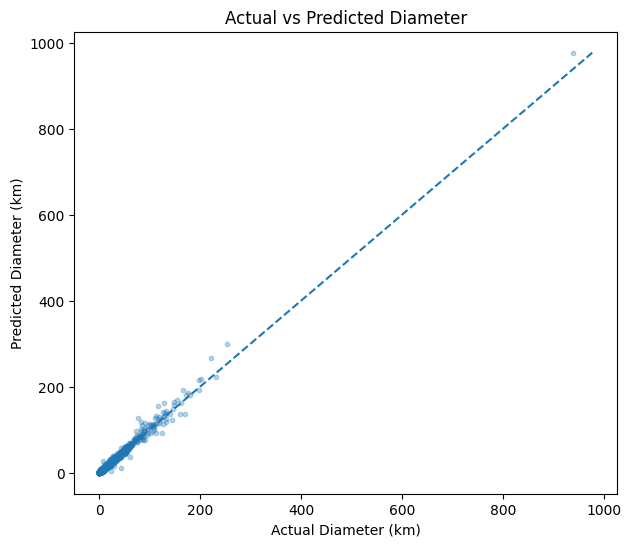

In [106]:
# Convert predictions back to original diameter scale
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

plt.figure(figsize=(7, 6))

plt.scatter(y_actual, y_pred, alpha=0.3, s=10)

# Perfect prediction line
min_val = min(y_actual.min(), y_pred.min())
max_val = max(y_actual.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual Diameter (km)')
plt.ylabel('Predicted Diameter (km)')
plt.title('Actual vs Predicted Diameter')

plt.show()

In [107]:
#Analytical qns
#1.MAE

In [110]:
y_actual = np.expm1(y_test)
y_pred = np.expm1(y_pred_log).flatten()

residuals = y_actual - y_pred
absolute_errors = np.abs(residuals)

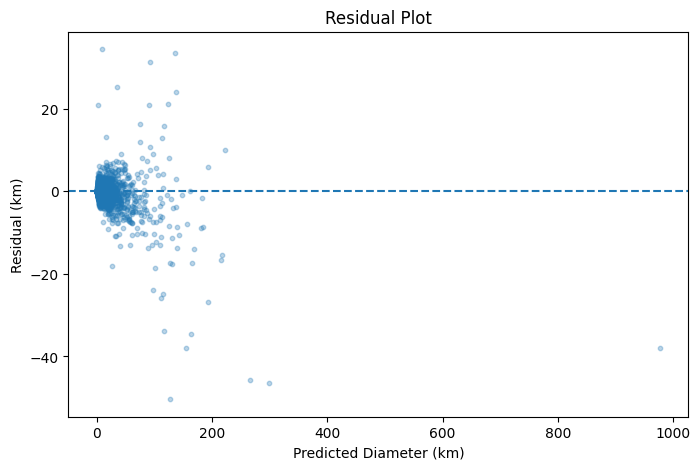

In [113]:
import numpy as np

y_actual = np.expm1(y_test)
y_pred = np.expm1(y_pred_log).flatten()

residuals = y_actual - y_pred

#RESIDUAL ERRORS
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.3, s=10)

plt.axhline(0, linestyle='--')

plt.xlabel('Predicted Diameter (km)')
plt.ylabel('Residual (km)')
plt.title('Residual Plot')

plt.show()

#DEPLOYING

In [114]:
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [115]:
model.save('asteroid_dnn.keras')

In [124]:
import os

print(os.path.exists("asteroid_dnn.keras"))
print(os.path.exists("scaler.pkl"))

True
True


In [125]:
!pip install streamlit

In [126]:
import streamlit as st
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# Load model and scaler
model = load_model("asteroid_dnn.keras")
scaler = joblib.load("scaler.pkl")

st.title("☄️ Asteroid Diameter Prediction")
st.write("Predict asteroid diameter using orbital and physical characteristics.")

st.header("Enter Asteroid Information")

H = st.number_input("Absolute Magnitude (H)", value=15.0)
albedo = st.number_input("Albedo", value=0.1, min_value=0.0)
e = st.number_input("Eccentricity", value=0.1, min_value=0.0)
a = st.number_input("Semi-major Axis (a)", value=2.5, min_value=0.0)
q = st.number_input("Perihelion Distance (q)", value=2.0, min_value=0.0)
i = st.number_input("Inclination (i)", value=5.0, min_value=0.0)
n = st.number_input("Mean Motion (n)", value=0.2, min_value=0.0)
moid = st.number_input("MOID", value=1.0, min_value=0.0)

if st.button("Predict Diameter"):

    input_data = np.array([
        [H, albedo, e, a, q, i, n, moid]
    ])

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Predict log-transformed diameter
    prediction_log = model.predict(input_scaled, verbose=0)

    # Convert back to km
    prediction = np.expm1(prediction_log)[0][0]

    st.success(f"Predicted Asteroid Diameter: {prediction:.2f} km")

2026-09-29 12:13:45.016 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 12:13:45.019 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 12:13:45.020 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 12:13:45.022 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 12:13:45.024 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 12:13:45.026 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 12:13:45.027 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 12:13:45.029 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [127]:
model.save("asteroid_dnn.keras")

In [128]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [129]:
import os

print("Model:", os.path.exists("asteroid_dnn.keras"))
print("Scaler:", os.path.exists("scaler.pkl"))

Model: True
Scaler: True


In [132]:
from google.colab import files

files.download("asteroid_dnn.keras")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>